In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
df.head(2)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk
0,19,male,3.8,Instagram,6.5,1.7,2.77,1.2,low,6,6,medium
1,16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high


In [38]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level
count,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,15.978000,4.45804,6.192440,1.714760,2.890944,0.991760,5.596400,5.164800
std,2.003577,2.01693,1.018734,0.716636,0.559553,0.586963,3.039013,3.002473
min,13.000000,1.00000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000
25%,14.000000,2.70000,5.500000,1.100000,2.420000,0.500000,3.000000,2.000000
50%,16.000000,4.40000,6.200000,1.700000,2.880000,1.000000,6.000000,5.000000
75%,18.000000,6.20000,6.900000,2.300000,3.340000,1.500000,8.000000,8.000000
max,19.000000,8.00000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        2500 non-null   int64  
 1    gender                    2500 non-null   str    
 2    daily_social_media_hours  2500 non-null   float64
 3    platform_usage            2500 non-null   str    
 4    sleep_hours               2500 non-null   float64
 5    screen_time_before_sleep  2500 non-null   float64
 6    academic_performance      2500 non-null   float64
 7    physical_activity         2500 non-null   float64
 8    social_interaction_level  2500 non-null   str    
 9    stress_level              2500 non-null   int64  
 10   anxiety_level             2500 non-null   int64  
 11   depression_risk           2500 non-null   str    
dtypes: float64(5), int64(3), str(4)
memory usage: 234.5 KB


In [40]:
df.columns = df.columns.str.strip()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2500 non-null   int64  
 1   gender                    2500 non-null   str    
 2   daily_social_media_hours  2500 non-null   float64
 3   platform_usage            2500 non-null   str    
 4   sleep_hours               2500 non-null   float64
 5   screen_time_before_sleep  2500 non-null   float64
 6   academic_performance      2500 non-null   float64
 7   physical_activity         2500 non-null   float64
 8   social_interaction_level  2500 non-null   str    
 9   stress_level              2500 non-null   int64  
 10  anxiety_level             2500 non-null   int64  
 11  depression_risk           2500 non-null   str    
dtypes: float64(5), int64(3), str(4)
memory usage: 234.5 KB


# ¿Cómo es el dataset?

### ¿Cuántas horas duermen en promedio? ¿Y el mínimo y máximo?

In [41]:
df["sleep_hours"].describe()

count    2500.000000
mean        6.192440
std         1.018734
min         4.000000
25%         5.500000
50%         6.200000
75%         6.900000
max         9.000000
Name: sleep_hours, dtype: float64

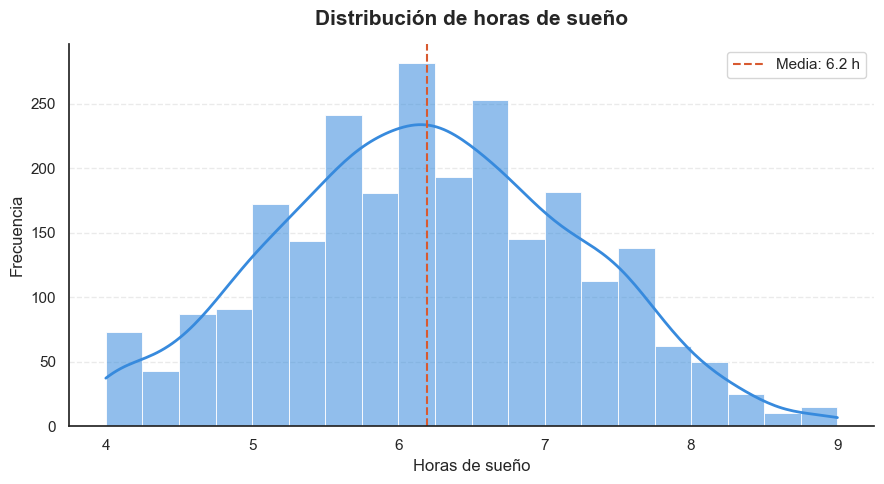

In [42]:
# Tema base limpio
sns.set_theme(style="white", font="sans-serif")

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="sleep_hours",
    kde=True,
    bins=20,
    color="#378ADD",       # azul principal
    alpha=0.55,
    edgecolor="white",
    linewidth=0.6,
    line_kws={"linewidth": 2, "color": "#0C447C"},
    ax=ax,
)

# Línea de la media
media = df["sleep_hours"].mean()
ax.axvline(media, color="#D85A30", linewidth=1.5,
           linestyle="--", label=f"Media: {media:.1f} h")

# Títulos y etiquetas
ax.set_title("Distribución de horas de sueño",
            fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Horas de sueño", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)

# Leyenda y grilla suave
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

### ¿Qué plataforma de redes sociales es la más popular?

In [43]:
df['platform_usage'].value_counts()

platform_usage
Other             632
Both              628
Instagram         627
TikTok            613
Name: count, dtype: int64

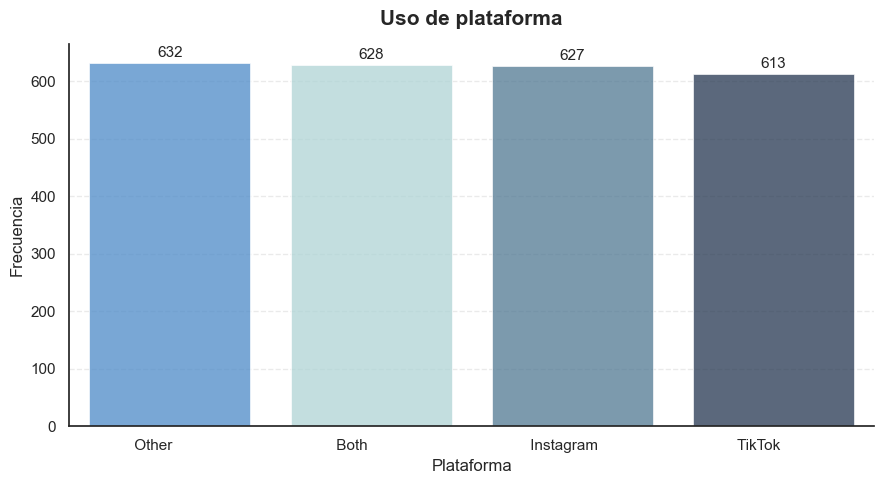

In [44]:
mis_colores = ["#378ADD", "#A8DADC", "#457B9D", "#1D3557"]

sns.set_theme(style="white", font="sans-serif")
fig, ax = plt.subplots(figsize=(9, 5))
counts = df['platform_usage'].value_counts()
sns.barplot(
    x=counts.index,
    y=counts.values,
    hue=counts.index,
    palette = mis_colores,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)
# Títulos y etiquetas
ax.set_title("Uso de plataforma",
            fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Plataforma", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
# Añadir valores encima de las barras
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

### ¿Cómo se distribuyen los niveles de estrés y ansiedad?

In [45]:
df[['stress_level','anxiety_level']]

,stress_level,anxiety_level
0,6,6
1,9,7
2,3,2
3,10,8
4,1,2
...,...,...
2495,5,5
2496,9,9
2497,9,10
2498,7,7


In [46]:
# Correlación exacta entre ambas
df[["stress_level", "anxiety_level"]].corr()

,stress_level,anxiety_level
stress_level,1.000000,0.949743
anxiety_level,0.949743,1.000000


In [47]:
# Estadísticas resumidas
df[["stress_level", "anxiety_level"]].describe()

,stress_level,anxiety_level
count,2500.000000,2500.000000
mean,5.596400,5.164800
std,3.039013,3.002473
min,1.000000,1.000000
25%,3.000000,2.000000
50%,6.000000,5.000000
75%,8.000000,8.000000
max,10.000000,10.000000


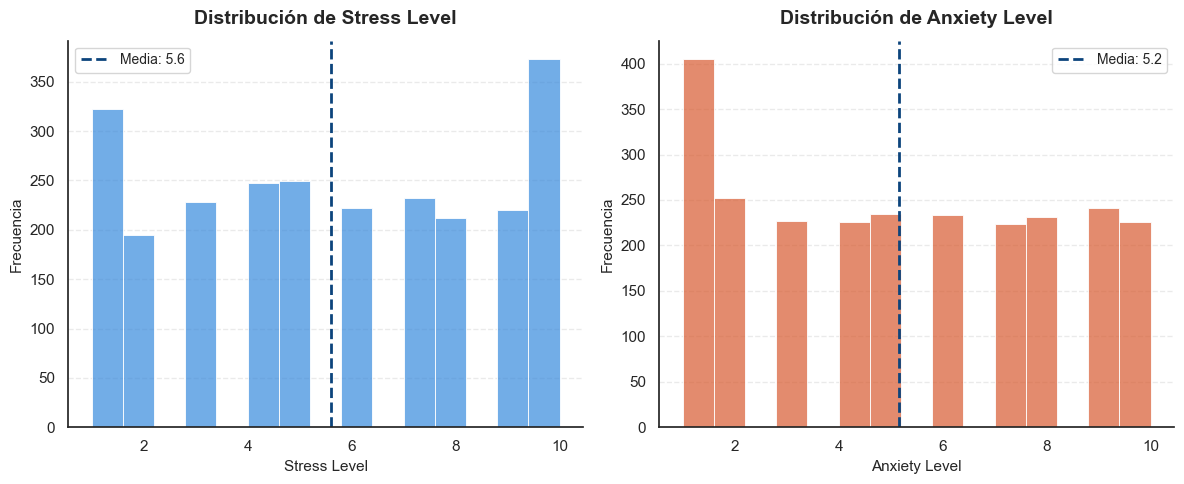

In [48]:
sns.set_theme(style="white", font="sans-serif")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, color in zip(axes, ['stress_level', 'anxiety_level'], ['#378ADD', '#D85A30']):
    sns.histplot(
        data=df,
        x=col,
        bins=15,
        color=color,
        alpha=0.7,
        edgecolor="white",
        linewidth=0.6,
        ax=ax,
    )
    
    media = df[col].mean()
    ax.axvline(media, color="#0C447C", linewidth=2, linestyle="--", label=f"Media: {media:.1f}")
    
    ax.set_title(f"Distribución de {col.replace('_', ' ').title()}", fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=11)
    ax.set_ylabel("Frecuencia", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

### ¿Cuántas personas tienen alto, medio y bajo riesgo de depresión?

In [49]:
df['depression_risk'].value_counts()

depression_risk
low       1266
medium     650
high       584
Name: count, dtype: int64

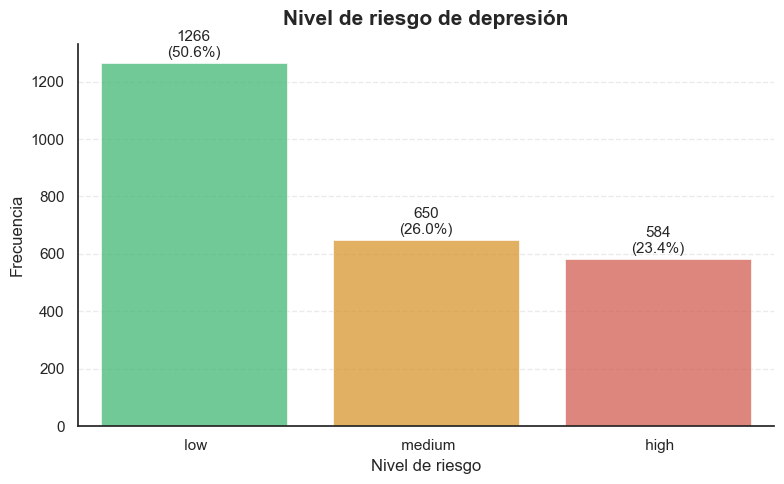

In [54]:
sns.set_theme(style="white", font="sans-serif")
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['depression_risk'].value_counts()
colores = ['#2ECC71','#F39C12','#E74C3C']
sns.barplot(
    x=counts.index,
    y=counts.values,
    hue=counts.index,
    palette=colores,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.6,
    legend=False,
    ax=ax,
)
ax.set_title("Nivel de riesgo de depresión", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Nivel de riesgo", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
for i, v in enumerate(counts.values):
    pct = v / len(df) * 100
    ax.text(i, v + 20, f"{v}\n({pct:.1f}%)", ha='center', fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()